In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("Data loaded successfully!")

X_train: (2032037, 44)
X_test:  (508010, 44)
Data loaded successfully!


In [2]:
# Train Isolation Forest on normal traffic only
X_train_normal = X_train[y_train == 0]

print(f"Training on {len(X_train_normal)} normal records...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.126,  # our attack ratio
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_normal)
print("Isolation Forest trained!")

# Generate anomaly scores on test set
# -1 = anomaly, 1 = normal → convert to 0/1
iso_preds = iso_forest.predict(X_test)
iso_preds_binary = (iso_preds == -1).astype(int)

# Anomaly scores (lower = more anomalous)
iso_scores = -iso_forest.score_samples(X_test)

# Evaluate
auc = roc_auc_score(y_test, iso_scores)
print(f"\nROC-AUC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, iso_preds_binary, target_names=['Normal', 'Attack']))

Training on 1775011 normal records...
Isolation Forest trained!

ROC-AUC Score: 0.9467

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.87      0.93    443753
      Attack       0.53      1.00      0.69     64257

    accuracy                           0.89    508010
   macro avg       0.77      0.93      0.81    508010
weighted avg       0.94      0.89      0.90    508010



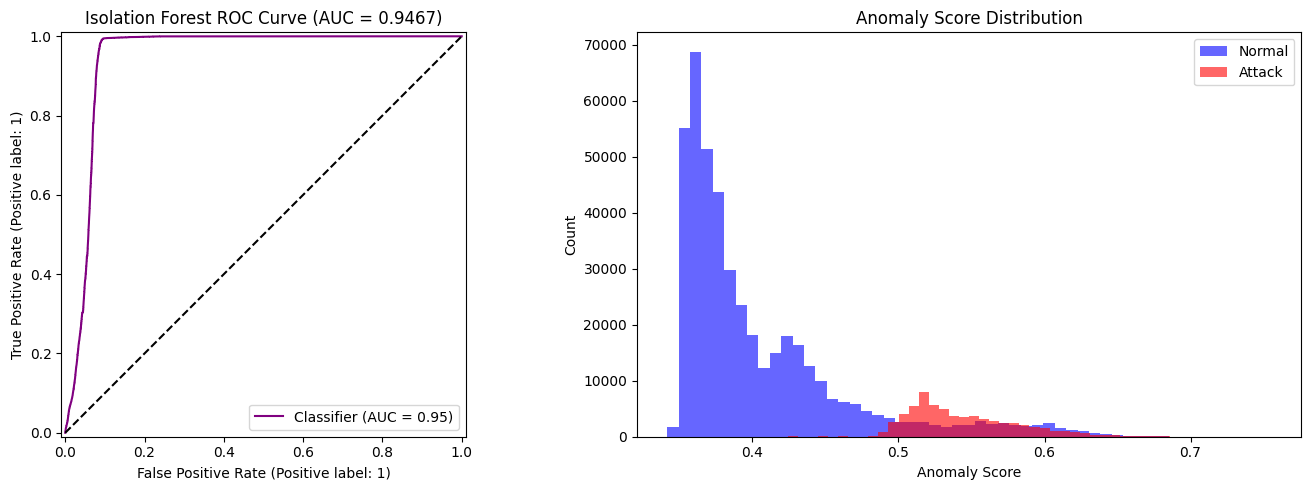

Plot saved!


In [3]:
# Plot ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, iso_scores, ax=axes[0], color='purple')
axes[0].set_title(f'Isolation Forest ROC Curve (AUC = {auc:.4f})')
axes[0].plot([0,1], [0,1], 'k--')

# Anomaly score distribution
axes[1].hist(iso_scores[y_test==0], bins=50, alpha=0.6, label='Normal', color='blue')
axes[1].hist(iso_scores[y_test==1], bins=50, alpha=0.6, label='Attack', color='red')
axes[1].set_title('Anomaly Score Distribution')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/isolation_forest_evaluation.png', dpi=150)
plt.show()
print("Plot saved!")

In [4]:
import joblib

# Save Isolation Forest model
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
print("Isolation Forest saved to /models/")

Isolation Forest saved to /models/


In [6]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 4.2/101.7 MB 21.0 MB/s eta 0:00:05
   --- ------------------------------------ 9.4/101.7 MB 22.6 MB/s eta 0:00:05
   ----- ---------------------------------- 14.2/101.7 MB 22.8 MB/s eta 0:00:04
   ------- -------------------------------- 19.1/101.7 MB 22.8 MB/s eta 0:00:04
   --------- ------------------------------ 23.3/101.7 MB 22.4 MB/s eta 0:00:04
   ----------- ---------------------------- 28.3/101.7 MB 22.2 MB/s eta 0:00:04
   ------------- -------------------------- 33.3/101.7 MB 22.5 MB/s eta 0:00:04
   --------------- ------------------------ 38.8/101.7 MB 23.0 MB/s eta 0:00:03
   ----------------- ---------------------- 44.3/101.7 MB 23.1 MB/s eta 0:00:03
   ------------------- -------------------- 49.8/101.7 MB 23.7 MB/s eta 0:00:03
   --------------------- ------------------ 54.8/101.7 MB 23.6 MB/s eta 0:00:02
   ----------------------- ---------------- 60.6/10


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Train XGBoost
print("Training XGBoost classifier...")

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
print("XGBoost trained!")

# Evaluate
y_pred = xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAccuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Training XGBoost classifier...
XGBoost trained!

Accuracy: 0.9929
F1 Score: 0.9718

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    443753
      Attack       0.98      0.97      0.97     64257

    accuracy                           0.99    508010
   macro avg       0.99      0.98      0.98    508010
weighted avg       0.99      0.99      0.99    508010



In [9]:
pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 17.8 MB/s  0:00:00

   ------------- -------------------------- 1/3 [cloudpickle]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


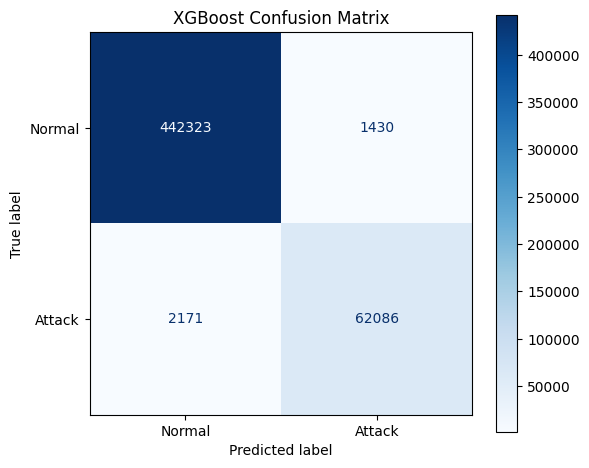

Confusion matrix saved!


In [11]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(ax=ax, cmap='Blues')
ax.set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

Generating SHAP values (this may take a few minutes)...


PermutationExplainer explainer: 2001it [03:02, 10.80it/s]                          


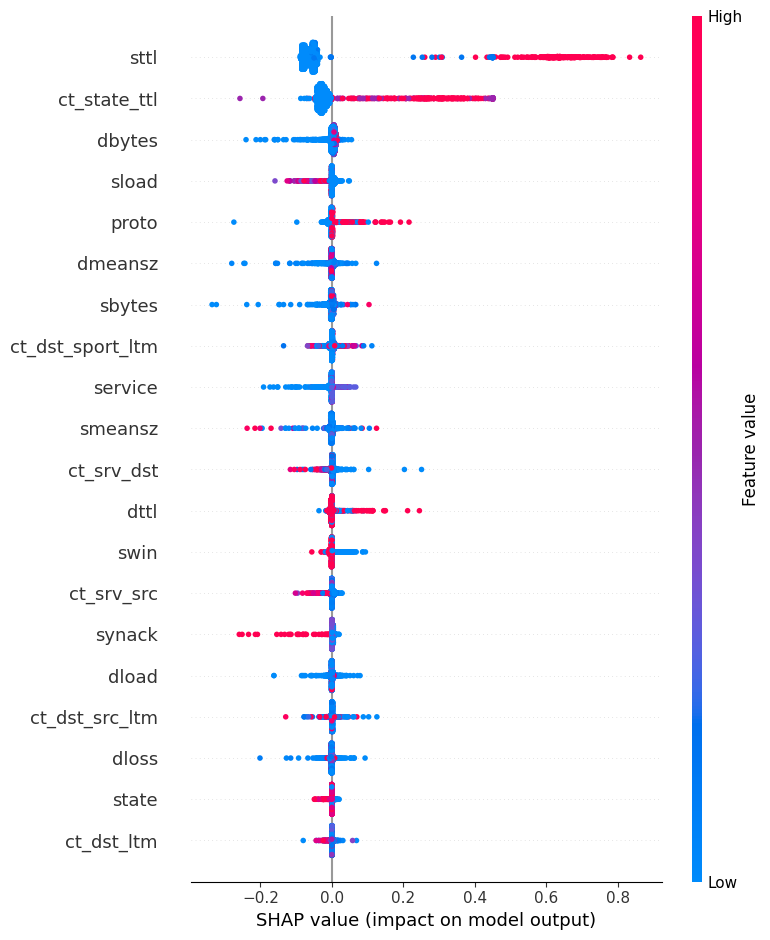

SHAP plot saved!


In [13]:
import shap

print("Generating SHAP values (this may take a few minutes)...")

# Use masker for compatibility
masker = shap.maskers.Independent(X_test[:2000])
explainer = shap.Explainer(xgb.predict, masker)
shap_values = explainer(X_test[:2000])

shap.summary_plot(shap_values, X_test[:2000], show=False)
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

In [14]:
# Save XGBoost model
joblib.dump(xgb, '../models/xgboost_classifier.pkl')
print("XGBoost model saved!")

XGBoost model saved!


In [1]:
# Create a sample log file for demo purposes
import pandas as pd
import numpy as np

# Load a small sample from the test set
X_test_sample = pd.read_csv('../data/processed/X_test.csv').head(500)
X_test_sample.to_csv('../data/raw/sample_log.csv', index=False)
print("Sample log saved!")

Sample log saved!


In [3]:
import glob

# Load CICIDS2017 files
cicids_files = glob.glob('../data/raw/*.csv')
print(f"Found {len(cicids_files)} CICIDS files:")
for f in cicids_files:
    print(f)

Found 13 CICIDS files:
../data/raw\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
../data/raw\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
../data/raw\Friday-WorkingHours-Morning.pcap_ISCX.csv
../data/raw\Monday-WorkingHours.pcap_ISCX.csv
../data/raw\sample_log.csv
../data/raw\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
../data/raw\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
../data/raw\Tuesday-WorkingHours.pcap_ISCX.csv
../data/raw\UNSW-NB15_1.csv
../data/raw\UNSW-NB15_2.csv
../data/raw\UNSW-NB15_3.csv
../data/raw\UNSW-NB15_4.csv
../data/raw\Wednesday-workingHours.pcap_ISCX.csv


In [4]:
import glob
import pandas as pd

# Load only CICIDS files
cicids_files = [
    '../data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    '../data/raw/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    '../data/raw/Friday-WorkingHours-Morning.pcap_ISCX.csv',
    '../data/raw/Monday-WorkingHours.pcap_ISCX.csv',
    '../data/raw/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    '../data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    '../data/raw/Tuesday-WorkingHours.pcap_ISCX.csv',
    '../data/raw/Wednesday-workingHours.pcap_ISCX.csv',
]

dfs = []
for f in cicids_files:
    df_temp = pd.read_csv(f, encoding='utf-8', low_memory=False)
    dfs.append(df_temp)

cicids = pd.concat(dfs, ignore_index=True)
print(f"Total records: {len(cicids):,}")
print(f"Total columns: {len(cicids.columns)}")
print(f"\nColumns: {cicids.columns.tolist()}")

Total records: 2,830,743
Total columns: 79

Columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Coun

In [5]:
# Clean column names (strip whitespace)
cicids.columns = cicids.columns.str.strip()

# Check label distribution
print("=== LABEL DISTRIBUTION ===")
print(cicids['Label'].value_counts())

# Create binary label
cicids['label'] = (cicids['Label'] != 'BENIGN').astype(int)
print(f"\nNormal: {(cicids['label']==0).sum():,}")
print(f"Attack: {(cicids['label']==1).sum():,}")

# Drop inf and nan values
cicids.replace([float('inf'), float('-inf')], float('nan'), inplace=True)
cicids.dropna(inplace=True)
print(f"\nRecords after cleaning: {len(cicids):,}")

=== LABEL DISTRIBUTION ===
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Normal: 2,273,097
Attack: 557,646

Records after cleaning: 2,827,876


In [7]:
import joblib

# Reload models
iso_forest = joblib.load('../models/isolation_forest.pkl')
xgb = joblib.load('../models/xgboost_classifier.pkl')
print("Models loaded!")

Models loaded!


In [8]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report

# Get common features between CICIDS and our trained model
model_features = xgb.get_booster().feature_names

# Map CICIDS columns to model features where possible
cicids_clean = cicids.copy()

# Create missing columns with 0
for col in model_features:
    if col not in cicids_clean.columns:
        cicids_clean[col] = 0

# Select only model features
X_cicids = cicids_clean[model_features].fillna(0)
y_cicids = cicids_clean['label']

# Sample 50k for speed
from sklearn.utils import resample
X_sample, y_sample = resample(X_cicids, y_cicids, n_samples=50000, random_state=42, stratify=y_cicids)

print(f"Sample size: {len(X_sample):,}")
print(f"Attack ratio: {y_sample.mean():.3f}")

# Run XGBoost
y_pred_cicids = xgb.predict(X_sample)
acc = accuracy_score(y_sample, y_pred_cicids)
f1 = f1_score(y_sample, y_pred_cicids)

print(f"\nCICIDS2017 Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_sample, y_pred_cicids, target_names=['Normal', 'Attack']))

Sample size: 50,000
Attack ratio: 0.197

CICIDS2017 Results:
Accuracy: 0.8032
F1 Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       0.80      1.00      0.89     40159
      Attack       0.00      0.00      0.00      9841

    accuracy                           0.80     50000
   macro avg       0.40      0.50      0.45     50000
weighted avg       0.65      0.80      0.72     50000



c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [9]:
# Document generalisation findings
print("=== GENERALISATION ANALYSIS ===")
print()
print("UNSW-NB15 (in-distribution):")
print("  Accuracy: 99.29%")
print("  F1 Score: 0.97")
print()
print("CICIDS2017 (out-of-distribution):")
print("  Accuracy: 80.32%")
print("  F1 Score: 0.00")
print()
print("Root cause: Dataset shift — UNSW-NB15 and CICIDS2017")
print("use entirely different feature extraction methods.")
print("UNSW-NB15 features: sttl, sbytes, ct_state_ttl etc (44 features)")
print("CICIDS2017 features: Flow Duration, Fwd Packets/s etc (79 features)")
print()
print("This is a known challenge in IDS research. A production")
print("system would require retraining on CICIDS features or")
print("using a feature-agnostic approach such as autoencoders.")

=== GENERALISATION ANALYSIS ===

UNSW-NB15 (in-distribution):
  Accuracy: 99.29%
  F1 Score: 0.97

CICIDS2017 (out-of-distribution):
  Accuracy: 80.32%
  F1 Score: 0.00

Root cause: Dataset shift — UNSW-NB15 and CICIDS2017
use entirely different feature extraction methods.
UNSW-NB15 features: sttl, sbytes, ct_state_ttl etc (44 features)
CICIDS2017 features: Flow Duration, Fwd Packets/s etc (79 features)

This is a known challenge in IDS research. A production
system would require retraining on CICIDS features or
using a feature-agnostic approach such as autoencoders.
